<a href="https://colab.research.google.com/github/gitmystuff/DTSC3010/blob/main/Week_09/Week_09_Modern_Advertising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modern Advertising Analytics


Welcome to a guided, end-to-end data science project.

You have already seen the classic advertising example in the `advertising_basic` and `plotly_advertising` notebooks.
In this notebook, you will extend that work by **modernizing the dataset** and walking through a complete data science lifecycle:

- Create the Data
- Data Prep
- Exploratory Data Analysis
- Feature Engineering
- Feature Selection
- Data Modeling
- Model Evaluation
- Model Fine-Tuning

This notebook starts with strong scaffolding and gradually asks you to make more independent decisions.
By the end, this should feel like a small example of the type of thinking you would use in a final semester project.

## Learning Goals

By the end of this notebook, you should be able to:

- explain how a project moves from raw data to a model
- create a modernized version of a classic dataset
- use AI to brainstorm domain-relevant features
- identify and handle missing values
- evaluate correlation with the target variable (`sales`)
- recognize multicollinearity among predictors
- justify feature selection choices
- train and compare at least two regression models
- reflect on how data prep affects modeling results

## Getting Started

* Colab - get notebook from the gitmystuff DTSC3010 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name
* Change the filename to your name - it should be the same as the name in the cell above
* Clean up Colab Notebooks folder
* Submit shared link

## Project Story

Imagine you work for a marketing analytics firm.

A client gives you an old dataset with advertising spend in:

- TV
- Radio
- Newspaper

and asks:

> "Can you modernize this project so it better reflects how advertising works today?"

Your task is to create a richer, more realistic dataset and then analyze how modern advertising features relate to **sales**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
url = "https://raw.githubusercontent.com/gitmystuff/Datasets/main/Advertising.csv"
df_base = pd.read_csv(url)
df_base = df_base.drop(columns=["Unnamed: 0"], errors="ignore")
df_base.head()

In [ ]:
print(df_base.shape)
df_base.info()

In [ ]:
df_base.describe().T

### Quick Reflection

Answer in your own words:

1. What is the target variable?
2. Which variables appear to be inputs or predictors?
3. Why does this dataset feel outdated for modern advertising?

## Brainstorm Modern Advertising Features with AI

A modern advertising project should include channels and metrics that did not exist in the original dataset.

Use an AI tool to brainstorm realistic modern advertising features.

### Suggested Prompt

Copy and paste this prompt into an AI tool:

**I have a dataset with TV, radio, newspaper, and sales. Suggest 8 modern advertising features that could plausibly influence sales today. Focus on realistic digital marketing and platform-based advertising variables. For each feature, include a short explanation of what it means and whether you expect its relationship with sales to be positive, weak, or possibly nonlinear.**

### Your Task

Write down 5 to 8 feature ideas that make sense for a modern advertising dataset.

Examples:
- influencer engagement
- streaming ad spend
- podcast ad spend
- social media impressions
- email click rate
- search ad conversions
- retargeting spend
- website sessions

## Generate Synthetic Features

## Create a Synthetic Modern Dataset

In the next cells, the notebook will generate **generic synthetic features** such as `feature_1`, `feature_2`, and so on.

Your job will be to:
1. inspect the patterns in the generated variables
2. use AI and your own judgment to assign meaningful modern advertising names
3. justify why those names make sense

This mirrors a common data science habit:
- first understand the data pattern
- then connect it to domain meaning

### Helper Functions

These functions create realistic numeric features, inject missing values, and add some feature relationships.
Read through them at a high level. You do not need to memorize every line.

In [ ]:
def make_null(series, pct):
    series = series.copy()
    n_missing = int(len(series) * pct)
    idx = np.random.choice(series.index, size=n_missing, replace=False)
    series.loc[idx] = np.nan
    return series

def gen_correlated_feature(base, noise_scale=0.25, multiplier=1.0, shift=0.0):
    z = (base - base.mean()) / base.std()
    noise = np.random.normal(0, noise_scale, len(base))
    return multiplier * (z + noise) + shift

def gen_positive_feature(base, noise_scale=0.35, multiplier=100):
    z = (base - base.mean()) / base.std()
    out = multiplier * np.exp(0.3 * z + np.random.normal(0, noise_scale, len(base)))
    return out

def gen_rate_feature(base, low=0.02, high=0.35, noise_scale=0.04):
    z = (base - base.mean()) / base.std()
    raw = 0.5 + 0.18 * z + np.random.normal(0, noise_scale, len(base))
    scaled = low + (high - low) * (raw - raw.min()) / (raw.max() - raw.min())
    return scaled.clip(low, high)

def add_duplicate_rows(df, n_rows=5):
    dupes = df.sample(n=n_rows, random_state=42)
    df2 = pd.concat([df, dupes], ignore_index=True)
    return df2.sample(frac=1, random_state=42).reset_index(drop=True)

def calculate_vif(X_numeric):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_temp = X_numeric.dropna().copy()
    X_temp = X_temp.loc[:, X_temp.nunique() > 1]
    vif_df = pd.DataFrame({
        "feature": X_temp.columns,
        "VIF": [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]
    })
    return vif_df.sort_values("VIF", ascending=False)

### Generate Generic Synthetic Features

These features are intentionally given generic names first.
Some are related to sales more strongly than others.
Some are also correlated with each other on purpose so that you can study multicollinearity later.

In [ ]:
df = df_base.copy()

sales = df["sales"]
tv = df["TV"]
radio = df["radio"]
news = df["newspaper"]

# Generic synthetic features
df["feature_1"] = gen_positive_feature(sales, noise_scale=0.18, multiplier=140)
df["feature_2"] = gen_correlated_feature(sales, noise_scale=0.22, multiplier=1.5)
df["feature_3"] = gen_rate_feature(sales, low=0.01, high=0.18, noise_scale=0.03)
df["feature_4"] = gen_positive_feature(tv + radio, noise_scale=0.25, multiplier=90)
df["feature_5"] = gen_correlated_feature(df["feature_2"].fillna(0), noise_scale=0.10, multiplier=1.1)
df["feature_6"] = gen_rate_feature(tv, low=0.03, high=0.28, noise_scale=0.05)
df["feature_7"] = gen_positive_feature(news + sales, noise_scale=0.40, multiplier=70)
df["feature_8"] = np.random.normal(0, 1, len(df))

# Derived synthetic features with generic names
df["feature_2_x_feature_4"] = df["feature_2"] * df["feature_4"]
df["feature_4_log"] = np.log1p(df["feature_4"])

# Add missing values to encourage data prep decisions
for col, pct in {
    "feature_1": 0.08,
    "feature_2": 0.12,
    "feature_3": 0.10,
    "feature_4": 0.06,
    "feature_5": 0.15,
    "feature_6": 0.10,
    "feature_7": 0.18,
    "feature_8": 0.05
}.items():
    df[col] = make_null(df[col], pct)

# Add a duplicate-prone version of one feature to create multicollinearity
df["feature_5_clone"] = df["feature_5"] * 0.97 + np.random.normal(0, 0.03, len(df))

# Add a few duplicate rows
df = add_duplicate_rows(df, n_rows=6)

print(df.shape)
df.head()

### Assign Modern Advertising Names

Now the dataset exists, but the feature names are generic.

Your next task is to **rename the generic features** using realistic modern advertising language.

You can use AI for help, but your final choices should make sense based on the patterns:

- positive spend-like variables might be ad budgets, impressions, or traffic
- rate-like variables might be click-through rate, conversion rate, or engagement rate
- highly correlated pairs may represent related channels or overlapping metrics

A good name should sound like a variable that could appear in a real advertising report.

In [ ]:
# # Example mapping only.
# # Replace these names with your own final choices after brainstorming.

# name_mapping = {
#     "feature_1": "some relevant name",
#     "feature_2": "some relevant name",
#     "feature_3": "some relevant name",
#     "feature_4": "some relevant name",
#     "feature_5": "some relevant name",
#     "feature_6": "some relevant name",
#     "feature_7": "some relevant name",
#     "feature_8": "some relevant name",
#     "feature_2_x_feature_4": "some relevant name_interaction",
#     "feature_4_log": "log_some relevant name",
#     "feature_5_clone": "some relevant name_clone"
# }

# df = df_base.rename(columns=name_mapping)
# df.head()

### Checkpoint Reflection

Write a short response:

1. Which names did you choose and why?
2. Which variables seem most likely to be modern advertising **spend** variables?
3. Which variables seem more like **engagement** or **conversion** variables?

## Introduce Missing Values

In [ ]:
df.loc[df.sample(frac=0.1).index, "feature_1"] = np.nan
df.loc[df.sample(frac=0.1).index, "feature_4"] = np.nan

df.isnull().sum()

## Data Prep

This is the most important section of the notebook.

In many real projects, the quality of the data prep matters as much as, or more than, the choice of model.

We will focus on:
- duplicates
- missing values
- imputation
- correlation to the target (`sales`)
- multicollinearity

### Check for Duplicate Rows

Because duplicate rows can distort analysis, this is one of the first checks to perform.

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df[df.duplicated()].head()

### Your Turn

Decide whether to keep or drop duplicate rows.

In most cases for this activity, dropping duplicates is reasonable.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

(200, 15)


### Check Missing Values

Now inspect the amount of missing data in each column.

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

### Decide How to Impute Missing Values

For numeric data, a common choice is:
- **mean imputation** when the distribution is roughly symmetric
- **median imputation** when the variable is skewed or has outliers

Before imputing, look at a few distributions.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols_to_plot = [c for c in numeric_cols if c != "sales"][:6]

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Guided Thinking

For each numeric column with missing values, ask:

- Does the histogram look skewed?
- Are there extreme values?
- Would the mean be pulled too much by outliers?

You will now create a simple imputation plan.

The first version below is scaffolded.
Later in the notebook, you will make more independent choices.

## Imputation

In [ ]:
median_impute_cols = [
    "feature_1",
    "feature_2",
    "feature_3"
]

mean_impute_cols = [
    "feature_4",
    "feature_5",
    "feature_6",
    "feature_7",
    "feature_8"
]

for col in median_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in mean_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()

### Independent Check

Now that the scaffolded imputation is done, answer:

1. Which columns did you impute with the median, and why?
2. Which columns did you impute with the mean, and why?
3. If this were a higher-stakes project, what other imputation methods might you consider?

## Correlation with Sales

### Correlation with the Target Variable (`sales`)

One important question in supervised learning is:

> Which features are most related to the target we want to predict?

Here, the target is `sales`.

In [ ]:
corr_to_sales = (
    df.corr(numeric_only=True)["sales"]
    .sort_values(ascending=False)
    .to_frame(name="correlation_with_sales")
)

corr_to_sales

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=corr_to_sales.reset_index().rename(columns={"index": "feature"}),
    x="correlation_with_sales",
    y="feature"
)
plt.title("Correlation of Numeric Features with Sales")
plt.axvline(0, color="black", linewidth=1)
plt.show()

### Guided Interpretation

Look carefully at the correlation table.

Discuss:

- Which variables have the strongest positive relationship with `sales`?
- Which variables appear weak?
- Did any of your modern synthetic features show useful predictive signal?
- Are there any variables that look suspiciously similar to each other?

### Multicollinearity

A predictor can correlate strongly with the target and still cause problems if it is also highly correlated with other predictors.

This is called **multicollinearity**.

Why does this matter?

- It can make coefficients unstable
- It can make interpretation harder
- It can cause the model to rely on redundant information

We will inspect this in two ways:
1. a correlation heatmap
2. VIF (Variance Inflation Factor)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix

corr = df.corr(numeric_only=True)

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
candidate_features = [c for c in df.select_dtypes(include=np.number).columns if c != "sales"]
vif_df = calculate_vif(df[candidate_features])
vif_df

### Multicollinearity Reflection

Use the heatmap and VIF results to answer:

1. Which features appear highly correlated with one another?
2. Is there a pair where keeping both may be unnecessary?
3. Which feature would you drop first if you wanted a simpler, more interpretable model?

Hint: if two features are nearly duplicates, you often keep the one with the clearer business meaning.

## Exploratory Data Analysis (EDA)

Now that the data is cleaner, we can explore relationships more intentionally.

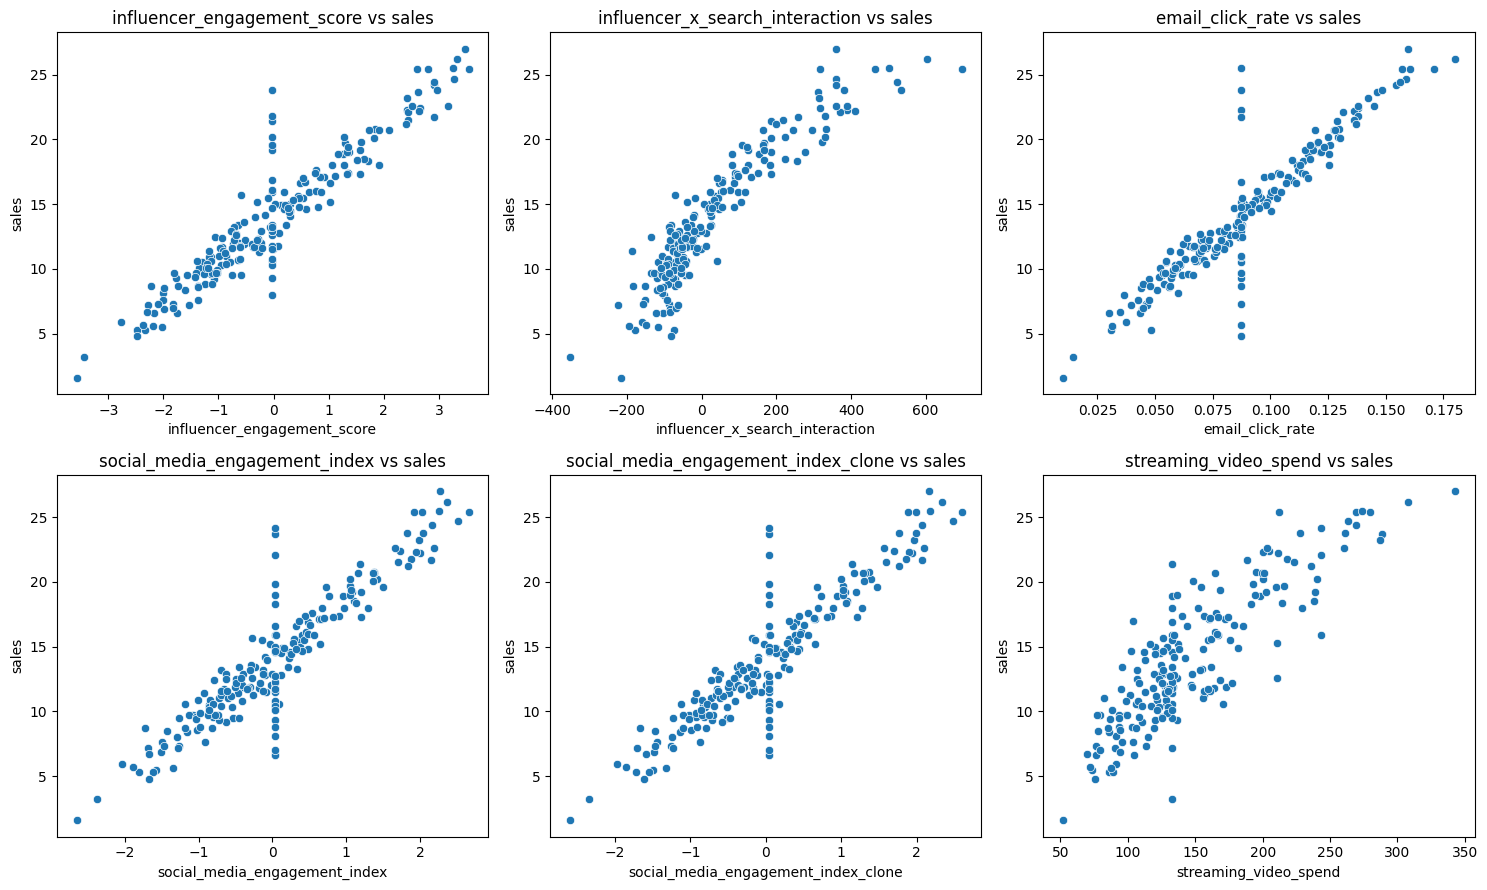

In [ ]:
top_features = corr_to_sales.drop(index="sales").head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), top_features):
    sns.scatterplot(data=df, x=col, y="sales", ax=ax)
    ax.set_title(f"{col} vs sales")
plt.tight_layout()
plt.show()

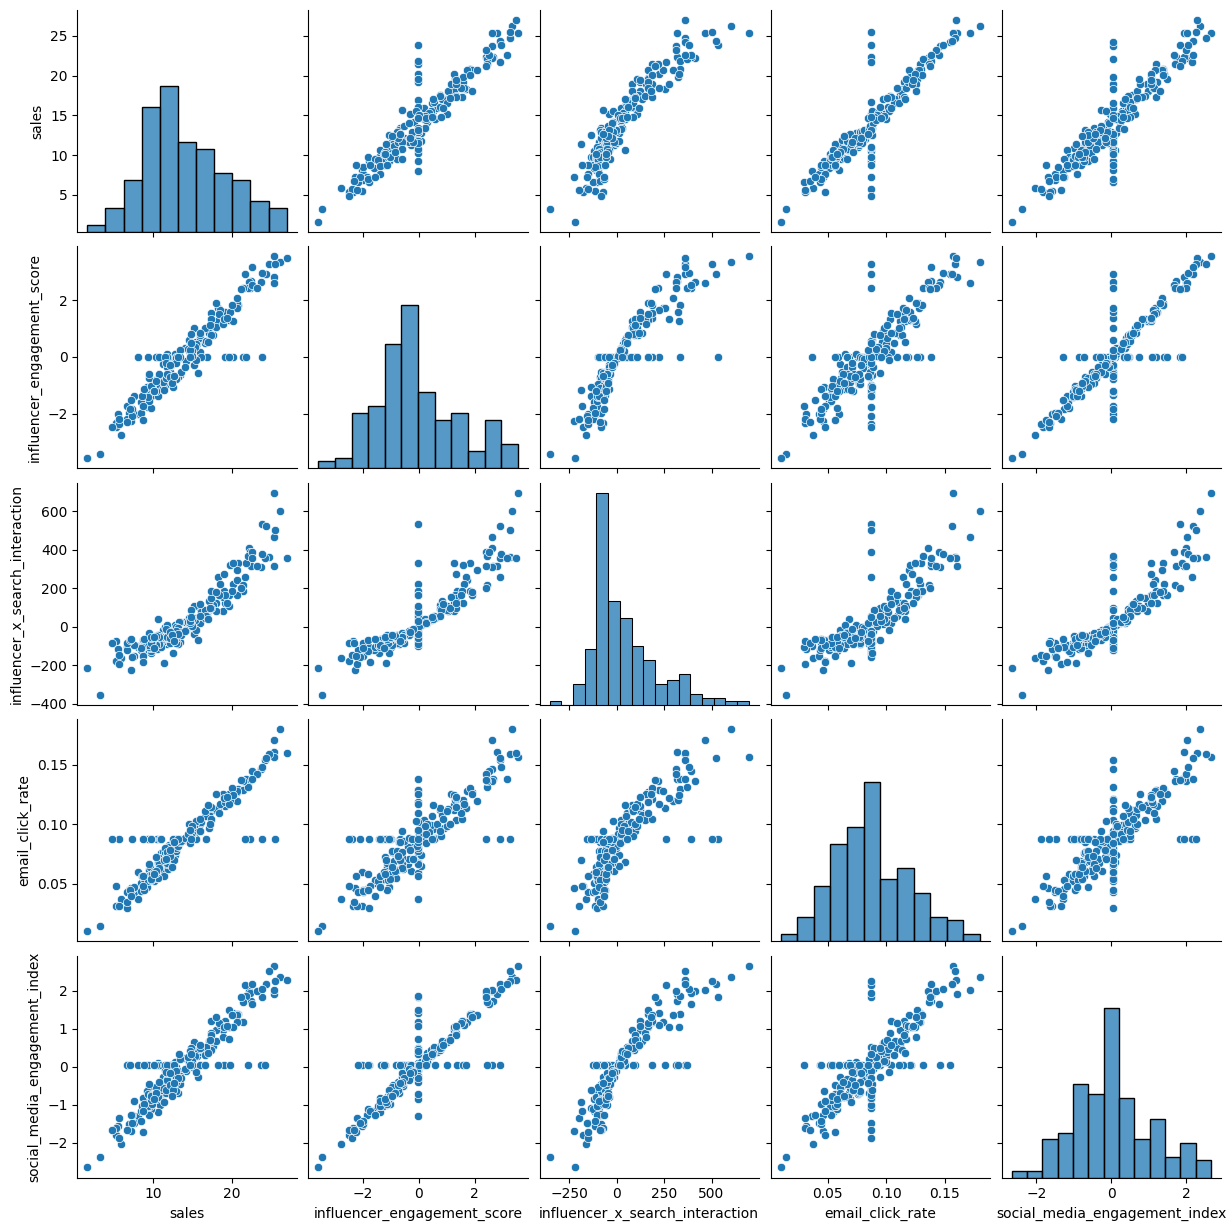

In [ ]:
sns.pairplot(df[["sales"] + top_features[:4]])
plt.show()

### EDA Reflection

Write a short interpretation:

- Which predictors show a roughly linear relationship with `sales`?
- Which look noisy or weak?
- Which might benefit from a transformation or interaction term?

## Feature Engineering

Now create a few new variables based on what you learned during EDA.

The first two are examples.
After that, you should add at least one of your own.

In [ ]:
# Scaffolded examples
if {"feature_1", "feature_4"}.issubset(df.columns):
    df["derived_variable_1"] = df["feature_1"] * df["feature_4"]

if "feature_7" in df.columns:
    df["derived_variable_2"] = np.log1p(df["feature_7"])

df.head()

### Your Turn

Create at least one additional engineered feature of your own.

Ideas:
- interaction term
- log transform
- ratio
- grouped metric
- squared term

Be ready to explain why the feature might help.

In [ ]:
# Example space for your own engineered feature
# Replace this with your own idea or add more features.
if {"feature_2", "feature_3"}.issubset(df.columns):
    df["derived_variable_3"] = df["feature_2"] * df["feature_3"]

df.head()

## Feature Selection

You should not automatically use every available predictor.

Good feature selection balances:
- correlation with sales
- multicollinearity
- interpretability
- simplicity

Start with a baseline model using the original classic variables.
Then create a modernized model using your selected features.

In [ ]:
baseline_features = ["TV", "radio", "newspaper"]

modern_feature_candidates = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != "sales"
]

print("Baseline features:", baseline_features)
print("\nModern feature candidates:")
modern_feature_candidates

### Your Turn

Create a final list called `selected_features`.

Guidelines:
- include variables that relate to `sales`
- avoid highly redundant variables when possible
- keep the list manageable

A good starting range is about 5 to 8 predictors.

In [ ]:
# Example starting point.
# Revise this list based on your own decisions.

selected_features = [
    "TV",
    "radio",
    "4 - 5 more features based on analysis"
]

selected_features = [c for c in selected_features if c in df.columns]
selected_features

## Data Modeling

We will compare:
1. a baseline linear regression model using the original advertising variables
2. a modernized model using your selected features
3. a regularized model for comparison

For fairness, we will use the same train/test split idea for both.

In [ ]:
X_baseline = df[baseline_features]
X_modern = df[selected_features]
y = df["sales"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_modern, y, test_size=0.2, random_state=42
)

In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(Xb_train, yb_train)
yb_pred = baseline_model.predict(Xb_test)

baseline_rmse = np.sqrt(mean_squared_error(yb_test, yb_pred))
baseline_r2 = r2_score(yb_test, yb_pred)

print("Baseline Linear Regression")
print("RMSE:", round(baseline_rmse, 3))
print("R^2 :", round(baseline_r2, 3))

Baseline Linear Regression
RMSE: 1.72
R^2 : 0.896


In [ ]:
modern_model = LinearRegression()
modern_model.fit(Xm_train, ym_train)
ym_pred = modern_model.predict(Xm_test)

modern_rmse = np.sqrt(mean_squared_error(ym_test, ym_pred))
modern_r2 = r2_score(ym_test, ym_pred)

print("Modern Feature Linear Regression")
print("RMSE:", round(modern_rmse, 3))
print("R^2 :", round(modern_r2, 3))

## Model Evaluation

Now compare the baseline model and your modernized model.

Questions to consider:
- Did the new features improve prediction?
- If performance improved, was the improvement meaningful?
- Did the modernized model become harder to interpret?

In [ ]:
comparison = pd.DataFrame({
    "model": ["Baseline Linear Regression", "Modern Linear Regression"],
    "RMSE": [baseline_rmse, modern_rmse],
    "R2": [baseline_r2, modern_r2]
})

comparison

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x="model", y="R2")
plt.title("Model Comparison: R^2")
plt.ylim(0, 1)
plt.show()

In [ ]:
residuals = ym_test - ym_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=ym_pred, y=residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted sales")
plt.ylabel("Residuals")
plt.title("Residual Plot for Modern Linear Regression")
plt.show()

### Evaluation Reflection

Respond in complete sentences:

1. Which model performed better?
2. Did the modern features seem useful?
3. Does the residual plot suggest any obvious pattern?
4. What does that pattern tell you about model fit?

## Model Fine-Tuning with Regularization

Because multicollinearity may exist, regularized models can be helpful.

We will try Ridge regression first.
This does not automatically make the model better, but it gives us a good comparison.

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Ridge Regression
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(Xm_train, ym_train)
ridge_pred = ridge_model.predict(Xm_test)

ridge_rmse = np.sqrt(mean_squared_error(ym_test, ridge_pred))
ridge_r2 = r2_score(ym_test, ridge_pred)

print("Ridge Regression")
print("RMSE:", round(ridge_rmse, 3))
print("R^2 :", round(ridge_r2, 3))

### Exploring

Try changing the value of `alpha` in Ridge.
You may also test Lasso.

Use what you have learned so far to decide whether the regularized model helps.

In [ ]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=10000))
])

lasso_model.fit(Xm_train, ym_train)
lasso_pred = lasso_model.predict(Xm_test)

lasso_rmse = np.sqrt(mean_squared_error(ym_test, lasso_pred))
lasso_r2 = r2_score(ym_test, lasso_pred)

print("Lasso Regression")
print("RMSE:", round(lasso_rmse, 3))
print("R^2 :", round(lasso_r2, 3))

In [ ]:
final_comparison = pd.DataFrame({
    "model": [
        "Baseline Linear Regression",
        "Modern Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE": [baseline_rmse, modern_rmse, ridge_rmse, lasso_rmse],
    "R2": [baseline_r2, modern_r2, ridge_r2, lasso_r2]
})

final_comparison.sort_values("R2", ascending=False)

## Final Reflection

This is the most important part of the notebook.

Write a short final reflection that answers the following:

1. Which synthetic features did you rename, and what modern advertising meanings did you assign to them?
2. Which data prep step mattered most: removing duplicates, imputing missing values, checking correlation to `sales`, or handling multicollinearity?
3. Which features were most useful for predicting `sales`?
4. Did your modern feature model outperform the baseline model?
5. If this were your semester project, what would you improve next?

## Final Project Connection

This notebook is meant to model the kind of thinking you can use in your final semester project:

- start with a question
- understand the data
- create or collect useful features
- clean the data carefully
- justify your prep decisions
- explore relationships
- select features thoughtfully
- model and evaluate
- reflect on what you learned

A strong final project is not just about getting the highest score.
It is about making defensible, thoughtful, data-driven decisions.